In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVR
from sklearn.neighbors import NearestNeighbors
from concurrent.futures import ProcessPoolExecutor

In [ ]:
# Load the dataset
all_available = pd.read_csv(r'C:\Users\Faculty\Desktop\Manoj_Honors\RF_csv\FT.csv')


# Prepare the feature set and target variable
X = all_available[['Time', 'Lat','Lon','PM2.5','Ozone']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")


C:\Users\Faculty\AppData\Local\Temp\ipykernel_46692\966317480.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 156.46 ± 2.32
Mean Absolute Error: 6.34 ± 0.02
R^2 Score: 0.87 ± 0.0
Mean Absolute Percentage Error: 38.24% ± 1.62%
Normalized RMSE: 0.0251 ± 0.0002


In [3]:
all_available = pd.read_csv(r'C:\Users\Faculty\Desktop\Manoj_Honors\RF_csv\all_available(t-1)_with_spatial.csv')
all_available.columns

Index(['Unnamed: 0', 'Time', 'Station_ID', 'PM2.5', 'Ozone', 'NO2', 'Date',
       'Average_PM2.5_t-1', 'Average_Ozone_t-1', 'Average_NO2_t-1', 'Station',
       'Lat', 'Lon', 'Spatial_Avg_PM2.5', 'Spatial_Avg_Ozone',
       'Spatial_Avg_NO2'],
      dtype='object')

In [2]:
# Load the dataset
all_available = pd.read_csv(r'D:\Manoj_Honors\RF_csv\all_available(t-1)_with_spatial.csv')

# Prepare the feature set with NO2 and the target variables
X = all_available[['Time', 'Lat', 'Lon', 'Ozone','Average_Ozone_t-1']]  
y = all_available[['PM2.5', 'NO2']]  

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold for both targets
mse_scores_pm25 = []
mae_scores_pm25 = []
r2_scores_pm25 = []
mape_scores_pm25 = []
nrmse_scores_pm25 = []

mse_scores_no2 = []
mae_scores_no2 = []
r2_scores_no2 = []
mape_scores_no2 = []
nrmse_scores_no2 = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Split predictions back into PM2.5 and Ozone
    y_pred_pm25 = y_pred[:, 0]
    y_pred_no2 = y_pred[:, 1]

    # Calculate evaluation metrics for PM2.5
    mse_pm25 = mean_squared_error(y_test['PM2.5'], y_pred_pm25)
    mae_pm25 = mean_absolute_error(y_test['PM2.5'], y_pred_pm25)
    r2_pm25 = r2_score(y_test['PM2.5'], y_pred_pm25)
    mape_pm25 = np.mean(np.abs((y_test['PM2.5'] - y_pred_pm25) / y_test['PM2.5'])) * 100
    nrmse_pm25 = np.sqrt(mse_pm25) / (y_test['PM2.5'].max() - y_test['PM2.5'].min())

    mse_no2 = mean_squared_error(y_test['NO2'], y_pred_no2)
    mae_no2 = mean_absolute_error(y_test['NO2'], y_pred_no2)
    r2_no2 = r2_score(y_test['NO2'], y_pred_no2)
    mape_no2 = np.mean(np.abs((y_test['NO2'] - y_pred_no2) / y_test['NO2'])) * 100
    nrmse_no2 = np.sqrt(mse_no2) / (y_test['NO2'].max() - y_test['NO2'].min())

    # Append metrics for PM2.5
    mse_scores_pm25.append(mse_pm25)
    mae_scores_pm25.append(mae_pm25)
    r2_scores_pm25.append(r2_pm25)
    mape_scores_pm25.append(mape_pm25)
    nrmse_scores_pm25.append(nrmse_pm25)

    # Append metrics for NO2
    mse_scores_no2.append(mse_no2)
    mae_scores_no2.append(mae_no2)
    r2_scores_no2.append(r2_no2)
    mape_scores_no2.append(mape_no2)
    nrmse_scores_no2.append(nrmse_no2)

# Calculate mean and standard deviation for each metric for PM2.5
mean_mse_pm25 = np.mean(mse_scores_pm25)
std_mse_pm25 = np.std(mse_scores_pm25)
mean_mae_pm25 = np.mean(mae_scores_pm25)
std_mae_pm25 = np.std(mae_scores_pm25)
mean_r2_pm25 = np.mean(r2_scores_pm25)
std_r2_pm25 = np.std(r2_scores_pm25)
mean_mape_pm25 = np.mean(mape_scores_pm25)
std_mape_pm25 = np.std(mape_scores_pm25)
mean_nrmse_pm25 = np.mean(nrmse_scores_pm25)
std_nrmse_pm25 = np.std(nrmse_scores_pm25)

# Calculate mean and standard deviation for each metric for Ozone
mean_mse_no2 = np.mean(mse_scores_no2)
std_mse_no2 = np.std(mse_scores_no2)
mean_mae_no2 = np.mean(mae_scores_no2)
std_mae_no2 = np.std(mae_scores_no2)
mean_r2_no2 = np.mean(r2_scores_no2)
std_r2_no2 = np.std(r2_scores_no2)
mean_mape_no2 = np.mean(mape_scores_no2)
std_mape_no2 = np.std(mape_scores_no2)
mean_nrmse_no2 = np.mean(nrmse_scores_no2)
std_nrmse_no2= np.std(nrmse_scores_no2)

# Print evaluation metrics for PM2.5
print(f"PM2.5 - Mean Squared Error: {round(mean_mse_pm25, 2)} ± {round(std_mse_pm25, 2)}")
print(f"PM2.5 - Mean Absolute Error: {round(mean_mae_pm25, 2)} ± {round(std_mae_pm25, 2)}")
print(f"PM2.5 - R^2 Score: {round(mean_r2_pm25, 2)} ± {round(std_r2_pm25, 2)}")
print(f"PM2.5 - Mean Absolute Percentage Error: {round(mean_mape_pm25, 2)}% ± {round(std_mape_pm25, 2)}%")
print(f"PM2.5 - Normalized RMSE: {round(mean_nrmse_pm25, 4)} ± {round(std_nrmse_pm25, 4)}")

# Print evaluation metrics for NO2
print(f"NO2 - Mean Squared Error: {round(mean_mse_no2, 2)} ± {round(std_mse_no2, 2)}")
print(f"NO2 - Mean Absolute Error: {round(mean_mae_no2, 2)} ± {round(std_mae_no2, 2)}")
print(f"NO2 - R^2 Score: {round(mean_r2_no2, 2)} ± {round(std_r2_no2, 2)}")
print(f"NO2- Mean Absolute Percentage Error: {round(mean_mape_no2, 2)}% ± {round(std_mape_no2, 2)}%")
print(f"NO2 - Normalized RMSE: {round(mean_nrmse_no2, 4)} ± {round(std_nrmse_no2, 4)}")

import joblib
model_output_path = r'D:\Manoj_Honors\random_forest_model_PM2.5_NO2.joblib'
joblib.dump(rf, model_output_path)

print(f"Model saved to {model_output_path}")


C:\Users\Faculty\AppData\Local\Temp\ipykernel_2824\132618444.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


PM2.5 - Mean Squared Error: 646.96 ± 19.16
PM2.5 - Mean Absolute Error: 14.12 ± 0.07
PM2.5 - R^2 Score: 0.92 ± 0.0
PM2.5 - Mean Absolute Percentage Error: 44.64% ± 3.14%
PM2.5 - Normalized RMSE: 0.0255 ± 0.0004
NO2 - Mean Squared Error: 131.6 ± 2.3
NO2 - Mean Absolute Error: 5.69 ± 0.01
NO2 - R^2 Score: 0.89 ± 0.0
NO2- Mean Absolute Percentage Error: 36.95% ± 2.09%
NO2 - Normalized RMSE: 0.023 ± 0.0002
Model saved to D:\Manoj_Honors\random_forest_model_PM2.5_NO2.joblib


In [2]:
import pandas as pd
import joblib

# File paths
model_path = r"D:\Manoj_Honors\random_forest_model_PM2.5_NO2.joblib"  # Assuming one model for both PM2.5 and NO2
input_csv_path = r'D:\Manoj_Honors\Imputed_Predictions(Univariate).csv'
output_csv_path = r"D:\Manoj_Honors\Imputed_Predictions(Univariate,(O3)).csv"

# Load the model
with open(model_path, 'rb') as model_file:
    rf_model = joblib.load(model_file)

# Load the input data
df = pd.read_csv(input_csv_path)

# Check the required columns
required_columns = ['Time', 'Lat', 'Lon', 'NO2', 'PM2.5', 'Average_Ozone_t-1', 'Ozone']
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Identify rows where both PM2.5 and NO2 are missing and Ozone is available
mask_missing_pm25_and_no2 = df['PM2.5'].isna() & df['NO2'].isna() & df['Ozone'].notna()

# Count rows with missing PM2.5 and NO2
missing_count = mask_missing_pm25_and_no2.sum()
print(f"Number of rows with missing PM2.5 and NO2 (but Ozone available): {missing_count}")

# Filter the rows where both PM2.5 and NO2 are missing and Ozone is available
rows_to_impute = df[mask_missing_pm25_and_no2]

# Prepare the features for imputation
X_to_impute = rows_to_impute[['Time', 'Lat', 'Lon', 'Ozone', 'Average_Ozone_t-1']]

# Convert 'Time' to seconds since epoch (as the model was likely trained on this format)
X_to_impute['Time'] = pd.to_datetime(X_to_impute['Time'], errors='coerce').astype('int64') // 10**9

# Ensure the columns are in the same order as during model training
train_columns = ['Time', 'Lat', 'Lon', 'Ozone', 'Average_Ozone_t-1']
X_to_impute = X_to_impute[train_columns]

# Impute the missing values using the model
imputed_values = rf_model.predict(X_to_impute)

# Assign the imputed values back to the appropriate columns
# Assume the model returns imputed values for both PM2.5 and NO2
df.loc[mask_missing_pm25_and_no2, ['PM2.5', 'NO2']] = imputed_values.reshape(-1, 2)

# Save the updated dataframe with imputed values to a new CSV
df.to_csv(output_csv_path, index=False)

print(f"Imputed rows and saved the updated data to {output_csv_path}")


Number of rows with missing PM2.5 and NO2 (but Ozone available): 2258


C:\Users\Faculty\AppData\Local\Temp\ipykernel_18352\838067643.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_to_impute['Time'] = pd.to_datetime(X_to_impute['Time'], errors='coerce').astype('int64') // 10**9


Imputed rows and saved the updated data to D:\Manoj_Honors\Imputed_Predictions(Univariate,(O3)).csv


C:\Users\Faculty\AppData\Local\Temp\ipykernel_259956\550300288.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_dropped['Time'] = pd.to_datetime(data_dropped['Time'])
C:\Users\Faculty\AppData\Local\Temp\ipykernel_259956\550300288.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_dropped['Hour'] = data_dropped['Time'].dt.hour
C:\Users\Faculty\AppData\Local\Temp\ipykernel_259956\550300288.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

Epoch 1/10


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14273/14273 ━━━━━━━━━━━━━━━━━━━━ 57s 4ms/step - loss: 0.0307 - r2_keras: 0.5173 - val_loss: 0.0091 - val_r2_keras: 0.8540 - learning_rate: 1.0000e-04
Epoch 2/10
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 53s 4ms/step - loss: 0.0046 - r2_keras: 0.9277 - val_loss: 0.0044 - val_r2_keras: 0.9296 - learning_rate: 1.0000e-04
Epoch 3/10
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 65s 5ms/step - loss: 0.0032 - r2_keras: 0.9490 - val_loss: 0.0031 - val_r2_keras: 0.9510 - learning_rate: 1.0000e-04
Epoch 4/10
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 77s 5ms/step - loss: 0.0028 - r2_keras: 0.9561 - val_loss: 0.0026 - val_r2_keras: 0.9591 - learning_rate: 1.0000e-04
Epoch 5/10
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 152s 11ms/step - loss: 0.0026 - r2_keras: 0.9597 - val_loss: 0.0024 - val_r2_keras: 0.9616 - learning_rate: 1.0000e-04
Epoch 6/10
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 206s 11ms/step - loss: 0.0024 - r2_keras: 0.9617 - val_loss: 0.0024 - val_r2_keras: 0.9618 - learning_rate: 1.0000e-04
Epoch 7/10
14273/14273 ━━━━━━━━━━━━━━━━━━

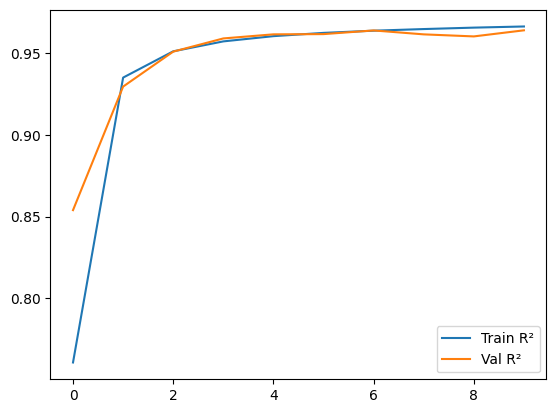

GRU Model saved as 'pollutant_forecasting_gru_model.keras'.
GRU Model loaded successfully.


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow.keras.backend as K
import math
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv(r'D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv')

# Drop rows with null values
data_dropped = data.dropna()

# Encode 'Time' into useful features
data_dropped['Time'] = pd.to_datetime(data_dropped['Time'])
data_dropped['Hour'] = data_dropped['Time'].dt.hour
data_dropped['Day'] = data_dropped['Time'].dt.day
data_dropped['Month'] = data_dropped['Time'].dt.month

# Positional encoding for Latitude and Longitude
data_dropped['Lat_sin'] = np.sin(np.radians(data_dropped['Lat']))
data_dropped['Lat_cos'] = np.cos(np.radians(data_dropped['Lat']))
data_dropped['Lon_sin'] = np.sin(np.radians(data_dropped['Lon']))
data_dropped['Lon_cos'] = np.cos(np.radians(data_dropped['Lon']))

# Drop original 'Time', 'Latitude', and 'Longitude'
data_dropped = data_dropped.drop(columns=['Time', 'Lat', 'Lon', 'Unnamed: 0'])

# Separate input features and targets
input_features = data_dropped.iloc[:, :-3]
target_features = data_dropped.iloc[:, -3:]

# Normalize input features and target features separately
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(input_features)
y_scaled = scaler_y.fit_transform(target_features)

# Combine scaled inputs and targets back for sequence splitting
data_scaled = np.hstack((X_scaled, y_scaled))

# Define a function to create sliding windows
def split_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_steps
        if end_ix >= len(data):
            break
        seq_x, seq_y = data[i:end_ix, :], data[end_ix, -3:]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Set the number of time steps
n_steps = 4

# Split into input (X) and output (y)
X, y = split_sequences(data_scaled, n_steps)

# Split into train and validation sets (80%-20%)
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# Get the number of features
n_features = X.shape[2]

# Define R² metric for Keras
def r2_keras(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# Build the GRU model
model = Sequential([
    GRU(100, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)),
    Dropout(0.2),
    GRU(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(3)  # Predicting 3 outputs (NO2, PM2.5, Ozone)
])

# Compile the model
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='mse', metrics=[r2_keras])

# Learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val),
                    callbacks=[lr_scheduler], verbose=1)

# Evaluate the model
y_pred = model.predict(X_val)

# Rescale predictions and true values to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_val_rescaled = scaler_y.inverse_transform(y_val)

# Calculate evaluation metrics
mse = mean_squared_error(y_val_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_val_rescaled, y_pred_rescaled)
rmse = math.sqrt(mse)
r2 = r2_score(y_val_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_val_rescaled - y_pred_rescaled) / y_val_rescaled)) * 100

# Print the evaluation metrics
print(f"MSE: {mse:.9f}")
print(f"MAE: {mae:.9f}")
print(f"RMSE: {rmse:.9f}")
print(f"R²: {r2:.9f}")
print(f"MAPE: {mape:.9f}%")

# Plot training and validation R²
plt.plot(history.history['r2_keras'], label='Train R²')
plt.plot(history.history['val_r2_keras'], label='Val R²')
plt.legend()
plt.show()

# Save the model
model.save('pollutant_forecasting_gru_model.keras')
print("GRU Model saved as 'pollutant_forecasting_gru_model.keras'.")

# Load the model to verify
loaded_model = load_model('pollutant_forecasting_gru_model.keras', custom_objects={'r2_keras': r2_keras})
print("GRU Model loaded successfully.")


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 73s 5ms/step - loss: 0.1756 - mae: 0.2353 - r2_keras: -32.1332 - val_loss: 0.0030 - val_mae: 0.0359 - val_r2_keras: 0.0390 - learning_rate: 1.0000e-04
Epoch 2/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 68s 5ms/step - loss: 0.0028 - mae: 0.0345 - r2_keras: 0.5115 - val_loss: 0.0024 - val_mae: 0.0312 - val_r2_keras: 0.2198 - learning_rate: 1.0000e-04
Epoch 3/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 93s 6ms/step - loss: 0.0024 - mae: 0.0310 - r2_keras: 0.5932 - val_loss: 0.0023 - val_mae: 0.0302 - val_r2_keras: 0.2485 - learning_rate: 1.0000e-04
Epoch 4/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 89s 6ms/step - loss: 0.0022 - mae: 0.0297 - r2_keras: 0.6243 - val_loss: 0.0023 - val_mae: 0.0300 - val_r2_keras: 0.2542 - learning_rate: 1.0000e-04
Epoch 5/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 67s 5ms/step - loss: 0.0021 - mae: 0.0289 - r2_keras: 0.6420 - val_loss: 0.0023 - val_mae: 0.0297 - val_r2_keras: 0.2545 - learning_rate: 1.0000e-04
Epoch 6/100
14273/14273 ━━━━

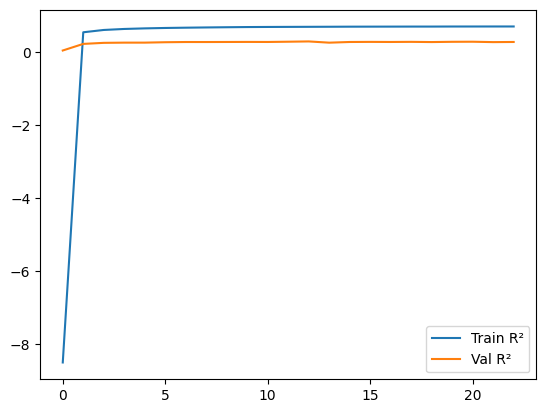

Model saved as 'pollutant_forecasting_model_gru_optimized.keras'.
Model loaded successfully.


In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow.keras.backend as K
import math
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv(r'D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv')

# Drop Null values first!
data = data.dropna()

# Drop 'Unnamed: 0' as it's just an index
data_dropped = data.drop(columns=['Unnamed: 0'])

# Convert 'Time' to datetime format and extract useful time features
data_dropped['Time'] = pd.to_datetime(data_dropped['Time'])
data_dropped['Hour'] = data_dropped['Time'].dt.hour
data_dropped['Day'] = data_dropped['Time'].dt.day
data_dropped['Month'] = data_dropped['Time'].dt.month

# Positional encoding for Latitude and Longitude
data_dropped['Lat_sin'] = np.sin(np.radians(data_dropped['Lat']))
data_dropped['Lat_cos'] = np.cos(np.radians(data_dropped['Lat']))
data_dropped['Lon_sin'] = np.sin(np.radians(data_dropped['Lon']))
data_dropped['Lon_cos'] = np.cos(np.radians(data_dropped['Lon']))

# Drop the 'Time', 'Lat', and 'Lon' columns
data_dropped = data_dropped.drop(columns=['Time', 'Lat', 'Lon'])

# Separate input features and target features
input_features = data_dropped.drop(columns=['NO2', 'PM2.5', 'Ozone'])
target_features = data_dropped[['NO2', 'PM2.5', 'Ozone']]

# Normalize input features and target features separately
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(input_features)
y_scaled = scaler_y.fit_transform(target_features)

# Combine scaled inputs and targets back for sequence splitting
data_scaled = np.hstack((X_scaled, y_scaled))

# Function to create sliding windows
def split_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_steps
        if end_ix >= len(data):
            break
        seq_x, seq_y = data[i:end_ix, :], data[end_ix, -3:]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Set the number of time steps
n_steps = 4

# Split into input (X) and output (y)
X, y = split_sequences(data_scaled, n_steps)

# Split into train and validation sets (80%-20%)
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

def r2_keras(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# Build the GRU model
model = Sequential([
    GRU(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    GRU(32, activation='relu', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    GRU(16, activation='relu'),
    BatchNormalization(),
    
    Dense(3)  # Predicting 3 outputs (NO2, PM2.5, Ozone)
])

# Compile the model
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae', r2_keras])

# Callbacks for regularization
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# Evaluate the model
y_pred = model.predict(X_val)

# Rescale predictions and true values to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_val_rescaled = scaler_y.inverse_transform(y_val)

# Function to calculate metrics for each pollutant
def calculate_metrics(y_true, y_pred, pollutant_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"Metrics for {pollutant_name}:")
    print(f"MSE: {mse:.9f}")
    print(f"MAE: {mae:.9f}")
    print(f"RMSE: {rmse:.9f}")
    print(f"R²: {r2:.9f}")
    print(f"MAPE: {mape:.9f}%")
    print("-" * 40)

# Split the predictions and actual values for each pollutant
y_pred_rescaled_NO2 = y_pred_rescaled[:, 0]
y_val_rescaled_NO2 = y_val_rescaled[:, 0]

y_pred_rescaled_PM25 = y_pred_rescaled[:, 1]
y_val_rescaled_PM25 = y_val_rescaled[:, 1]

y_pred_rescaled_Ozone = y_pred_rescaled[:, 2]
y_val_rescaled_Ozone = y_val_rescaled[:, 2]

# Calculate metrics for each pollutant
calculate_metrics(y_val_rescaled_NO2, y_pred_rescaled_NO2, "NO2")
calculate_metrics(y_val_rescaled_PM25, y_pred_rescaled_PM25, "PM2.5")
calculate_metrics(y_val_rescaled_Ozone, y_pred_rescaled_Ozone, "Ozone")

# Plot training and validation R²
plt.plot(history.history['r2_keras'], label='Train R²')
plt.plot(history.history['val_r2_keras'], label='Val R²')
plt.legend()
plt.show()

# Save the model
model.save('pollutant_forecasting_model_gru_optimized.keras')
print("Model saved as 'pollutant_forecasting_model_gru_optimized.keras'.")

# Load the model to verify
loaded_model = load_model('pollutant_forecasting_model_gru_optimized.keras', custom_objects={'r2_keras': r2_keras})
print("Model loaded successfully.")

Epoch 1/150
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 374s 13ms/step - loss: 0.0036 - mae: 0.0370 - r2_keras: 0.3601 - val_loss: 0.0026 - val_mae: 0.0317 - val_r2_keras: 0.1799 - learning_rate: 0.0010
Epoch 2/150
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 399s 14ms/step - loss: 0.0021 - mae: 0.0293 - r2_keras: 0.6265 - val_loss: 0.0025 - val_mae: 0.0304 - val_r2_keras: 0.2240 - learning_rate: 0.0010
Epoch 3/150
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 407s 14ms/step - loss: 0.0020 - mae: 0.0284 - r2_keras: 0.6463 - val_loss: 0.0025 - val_mae: 0.0300 - val_r2_keras: 0.2199 - learning_rate: 0.0010
Epoch 4/150
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 349s 12ms/step - loss: 0.0020 - mae: 0.0280 - r2_keras: 0.6570 - val_loss: 0.0023 - val_mae: 0.0298 - val_r2_keras: 0.2581 - learning_rate: 0.0010
Epoch 5/150
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 364s 13ms/step - loss: 0.0019 - mae: 0.0277 - r2_keras: 0.6624 - val_loss: 0.0025 - val_mae: 0.0309 - val_r2_keras: 0.1397 - learning_rate: 0.0010
Epoch 6/150
28545/28545 ━━━━━━━━━━━━━━━━

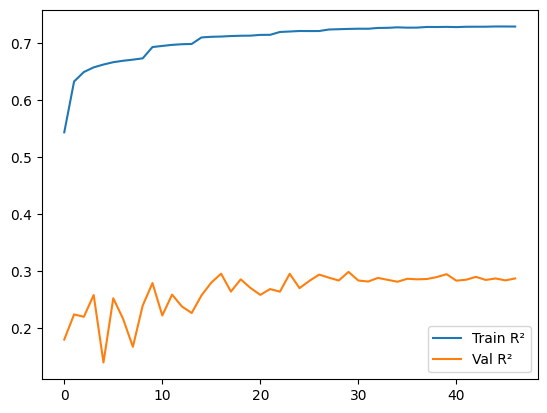

Transformer model saved as 'optimized_pollutant_transformer_model.keras'.


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow.keras.backend as K
import math
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv(r'D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv')

# Drop Null values
data = data.dropna()

# Drop 'Unnamed: 0' as it's just an index
data_dropped = data.drop(columns=['Unnamed: 0'])

# Convert 'Time' to datetime format and extract useful time features
data_dropped['Time'] = pd.to_datetime(data_dropped['Time'])
data_dropped['Hour'] = data_dropped['Time'].dt.hour
data_dropped['Day'] = data_dropped['Time'].dt.day
data_dropped['Month'] = data_dropped['Time'].dt.month

# Positional encoding for Latitude and Longitude
data_dropped['Lat_sin'] = np.sin(np.radians(data_dropped['Lat']))
data_dropped['Lat_cos'] = np.cos(np.radians(data_dropped['Lat']))
data_dropped['Lon_sin'] = np.sin(np.radians(data_dropped['Lon']))
data_dropped['Lon_cos'] = np.cos(np.radians(data_dropped['Lon']))

# Drop the 'Time', 'Lat', and 'Lon' columns
data_dropped = data_dropped.drop(columns=['Time', 'Lat', 'Lon'])

# Separate input features and target features
input_features = data_dropped.drop(columns=['NO2', 'PM2.5', 'Ozone'])
target_features = data_dropped[['NO2', 'PM2.5', 'Ozone']]

# Normalize input features and target features separately
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(input_features)
y_scaled = scaler_y.fit_transform(target_features)

# Combine scaled inputs and targets back for sequence splitting
data_scaled = np.hstack((X_scaled, y_scaled))

# Function to create sliding windows
def split_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_steps
        if end_ix >= len(data):
            break
        seq_x, seq_y = data[i:end_ix, :], data[end_ix, -3:]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Set the number of time steps
n_steps = 4

# Split into input (X) and output (y)
X, y = split_sequences(data_scaled, n_steps)

# Split into train and validation sets (80%-20%)
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# Custom R² metric
def r2_keras(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# Define the transformer block
def transformer_encoder(inputs, num_heads, ff_dim, dropout_rate):
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=inputs.shape[-1])(inputs, inputs)
    attention_output = Dropout(dropout_rate)(attention_output)
    attention_output = LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    ff_output = Dense(ff_dim, activation="relu")(attention_output)
    ff_output = Dense(inputs.shape[-1])(ff_output)
    ff_output = Dropout(dropout_rate)(ff_output)
    ff_output = LayerNormalization(epsilon=1e-6)(attention_output + ff_output)

    return ff_output

# Define the transformer model
def build_transformer_model(input_shape, num_heads, ff_dim, num_layers, dropout_rate):
    inputs = Input(shape=input_shape)
    x = inputs

    # Apply transformer layers
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, ff_dim, dropout_rate)

    # Global average pooling to reduce the sequence dimension
    x = GlobalAveragePooling1D()(x)

    # Fully connected layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    # Output layer (3 pollutants)
    outputs = Dense(3)(x)
    model = Model(inputs, outputs)

    return model

# Build the model
input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)
transformer_model = build_transformer_model(
    input_shape=input_shape,
    num_heads=8,
    ff_dim=128,
    num_layers=4,
    dropout_rate=0.3
)

# Compile the model
transformer_model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae', r2_keras])

# Callbacks for regularization
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

# Train the transformer model
history_transformer = transformer_model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# Evaluate the model
y_pred_transformer = transformer_model.predict(X_val)

# Rescale predictions
y_pred_transformer_rescaled = scaler_y.inverse_transform(y_pred_transformer)
y_val_rescaled = scaler_y.inverse_transform(y_val)

# Function to calculate metrics for each pollutant
def calculate_metrics(y_true, y_pred, pollutant_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"Metrics for {pollutant_name}:")
    print(f"MSE: {mse:.9f}")
    print(f"MAE: {mae:.9f}")
    print(f"RMSE: {rmse:.9f}")
    print(f"R²: {r2:.9f}")
    print(f"MAPE: {mape:.9f}%")
    print("-" * 40)

# Calculate metrics for each pollutant
calculate_metrics(y_val_rescaled[:, 0], y_pred_transformer_rescaled[:, 0], "NO2")
calculate_metrics(y_val_rescaled[:, 1], y_pred_transformer_rescaled[:, 1], "PM2.5")
calculate_metrics(y_val_rescaled[:, 2], y_pred_transformer_rescaled[:, 2], "Ozone")

# Plot training and validation R²
plt.plot(history_transformer.history['r2_keras'], label='Train R²')
plt.plot(history_transformer.history['val_r2_keras'], label='Val R²')
plt.legend()
plt.show()

# Save the transformer model
transformer_model.save('optimized_pollutant_transformer_model.keras')
print("Transformer model saved as 'optimized_pollutant_transformer_model.keras'.")


In [2]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2']]
y = all_available['Ozone']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

# import pickle

# with open('random_forest_model_PM2.5.pkl', 'wb') as model_file:
#     pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_8012\1730882431.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_8012\1730882431.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 227.91 ± 0.84
Mean Absolute Error: 8.67 ± 0.02
R^2 Score: 0.81 ± 0.0
Mean Absolute Percentage Error: 105.94% ± 2.63%
Normalized RMSE: 0.0755 ± 0.0001
